In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load your dataset
df = pd.read_csv('heart.csv')
print(df.shape)        # (1025, 14)
print(df.isnull().sum().sum())  # 0 — no missing values

X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80/20, stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

(1025, 14)
0
Train: (820, 13), Test: (205, 13)


In [2]:
# Train with no depth limit first
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_full.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_full.predict(X_test))

print(f"Train Accuracy : {train_acc:.4f}")   # 1.0000
print(f"Test  Accuracy : {test_acc:.4f}")    # 0.9854
print(f"Tree Depth     : {dt_full.get_depth()}")  # 9

Train Accuracy : 1.0000
Test  Accuracy : 0.9854
Tree Depth     : 9


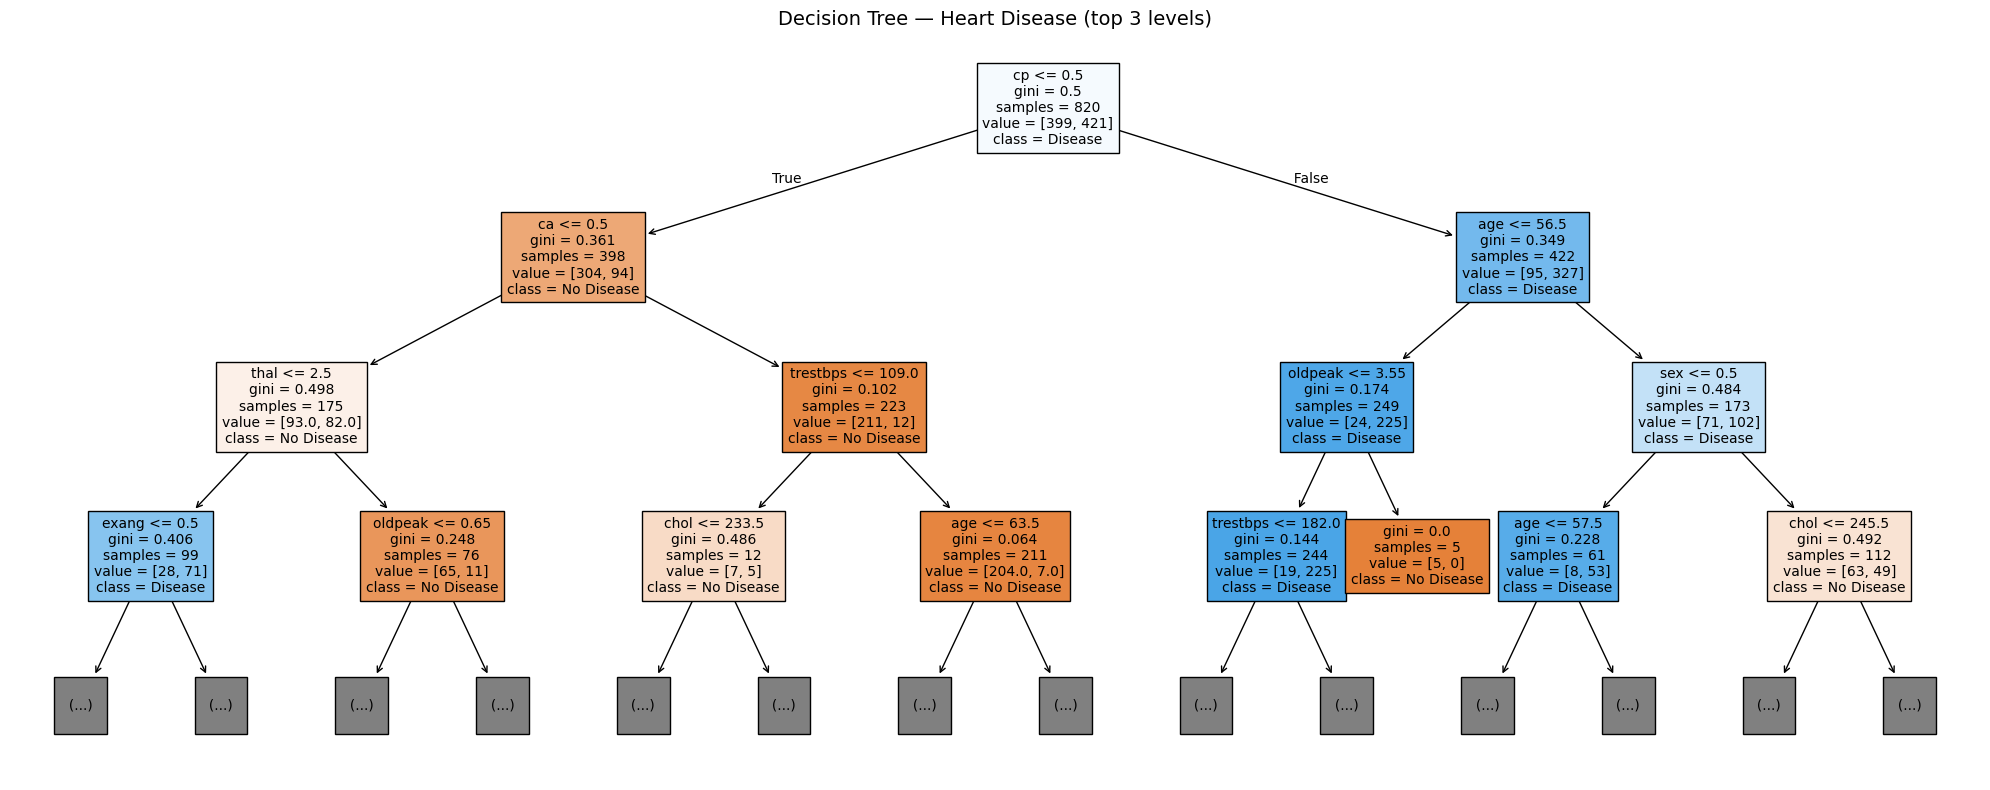

In [3]:
# Visualize the tree (best for small depth)
plt.figure(figsize=(20, 8))
plot_tree(
    dt_full,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True,
    max_depth=3,      # show top 3 levels only for readability
    fontsize=10
)
plt.title('Decision Tree — Heart Disease (top 3 levels)', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Text representation (easy to read in notebook)
print(export_text(dt_full, feature_names=X.columns.tolist(), max_depth=4))

|--- cp <= 0.50
|   |--- ca <= 0.50
|   |   |--- thal <= 2.50
|   |   |   |--- exang <= 0.50
|   |   |   |   |--- thalach <= 96.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- thalach >  96.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- exang >  0.50
|   |   |   |   |--- restecg <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- restecg >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- thal >  2.50
|   |   |   |--- oldpeak <= 0.65
|   |   |   |   |--- age <= 42.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  42.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- oldpeak >  0.65
|   |   |   |   |--- class: 0
|   |--- ca >  0.50
|   |   |--- trestbps <= 109.00
|   |   |   |--- chol <= 233.50
|   |   |   |   |--- class: 1
|   |   |   |--- chol >  233.50
|   |   |   |   |--- class: 0
|   |   |--- trestbps >  109.00
|   |   |   |--- age <= 63.50
|   |   |   |   |--- chol <= 301.50
|

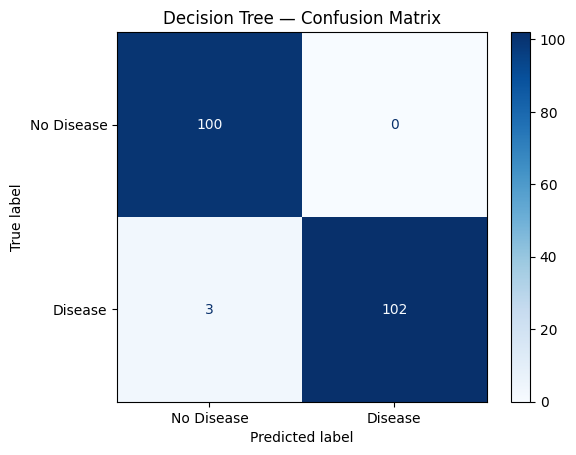

In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, dt_full.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

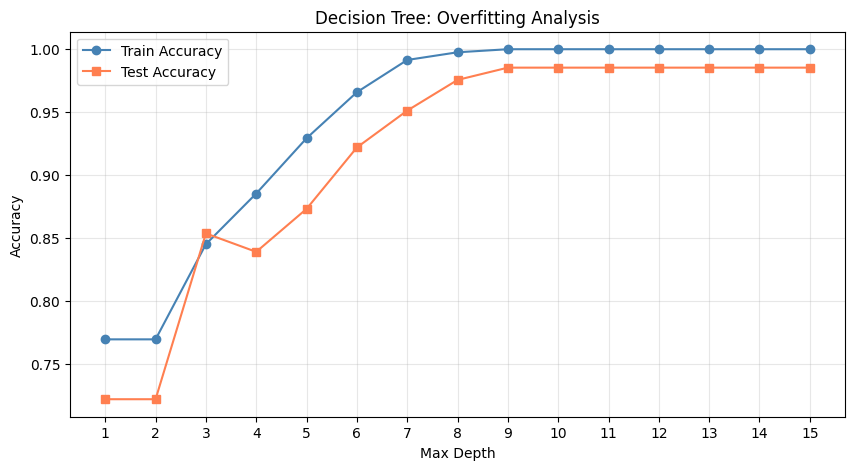

Best depth: 9, Test accuracy: 0.9854


In [6]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  dt.predict(X_test)))

# Plot the overfitting curve
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_scores,  's-', label='Test Accuracy',  color='coral')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting Analysis')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find best depth
best_depth = list(depths)[test_scores.index(max(test_scores))]
print(f"Best depth: {best_depth}, Test accuracy: {max(test_scores):.4f}")

In [7]:
# Train the pruned/optimal tree
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
print(classification_report(y_test, dt_best.predict(X_test),
                             target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       100
     Disease       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [8]:
# Train Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_train = accuracy_score(y_train, rf.predict(X_train))
rf_test  = accuracy_score(y_test,  rf.predict(X_test))

print(f"Random Forest Train : {rf_train:.4f}")   # 1.0000
print(f"Random Forest Test  : {rf_test:.4f}")    # 1.0000
print()
print(classification_report(y_test, rf.predict(X_test),
                             target_names=['No Disease', 'Disease']))

Random Forest Train : 1.0000
Random Forest Test  : 1.0000

              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



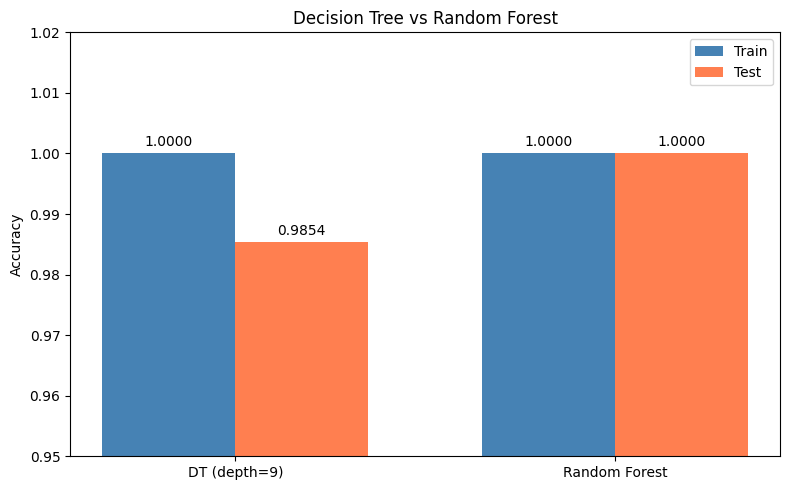

In [9]:
# Side-by-side comparison bar chart
models     = ['DT (depth=9)', 'Random Forest']
train_accs = [accuracy_score(y_train, dt_best.predict(X_train)), rf_train]
test_accs  = [accuracy_score(y_test,  dt_best.predict(X_test)),  rf_test]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test',  color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.95, 1.02)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

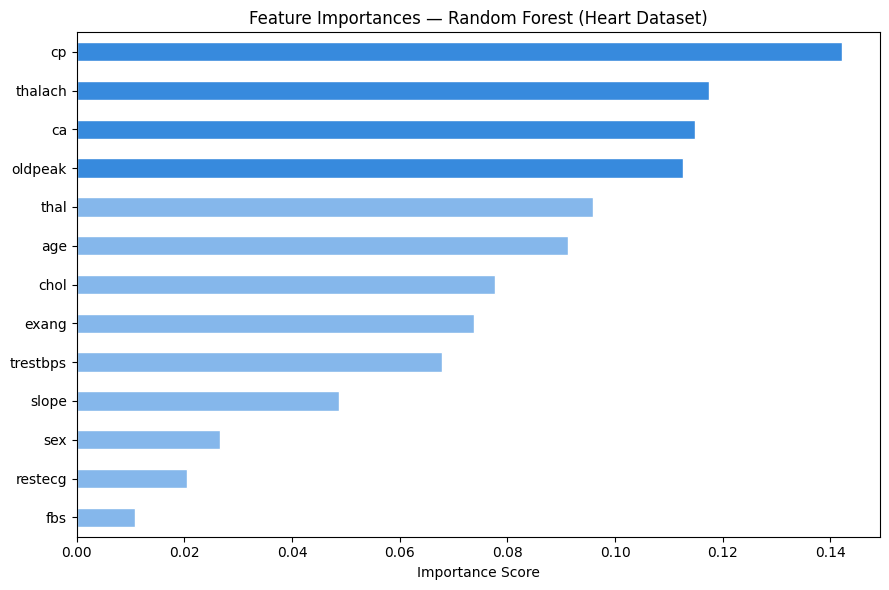

cp          0.142094
thalach     0.117349
ca          0.114844
oldpeak     0.112634
thal        0.095930
age         0.091285
chol        0.077771
exang       0.073707
trestbps    0.067765
slope       0.048711
sex         0.026682
restecg     0.020438
fbs         0.010790
dtype: float64


In [10]:
# Extract and plot feature importances from Random Forest
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)  # ascending for horizontal barh

plt.figure(figsize=(9, 6))
colors = ['#378ADD' if v > 0.10 else '#85B7EB' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importances — Random Forest (Heart Dataset)')
plt.tight_layout()
plt.show()

# Print values
print(feat_imp.sort_values(ascending=False))

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate both models with 5-fold CV
dt_cv_scores = cross_val_score(dt_best, X, y, cv=cv, scoring='accuracy')
rf_cv_scores = cross_val_score(rf,      X, y, cv=cv, scoring='accuracy')

print("Decision Tree — 5-Fold CV:")
print(f"  Scores : {dt_cv_scores.round(4)}")
print(f"  Mean   : {dt_cv_scores.mean():.4f}")
print(f"  Std    : {dt_cv_scores.std():.4f}")

print("\nRandom Forest — 5-Fold CV:")
print(f"  Scores : {rf_cv_scores.round(4)}")
print(f"  Mean   : {rf_cv_scores.mean():.4f}")
print(f"  Std    : {rf_cv_scores.std():.4f}")

Decision Tree — 5-Fold CV:
  Scores : [1.     1.     1.     0.9854 1.    ]
  Mean   : 0.9971
  Std    : 0.0059

Random Forest — 5-Fold CV:
  Scores : [1.     1.     1.     0.9805 1.    ]
  Mean   : 0.9961
  Std    : 0.0078


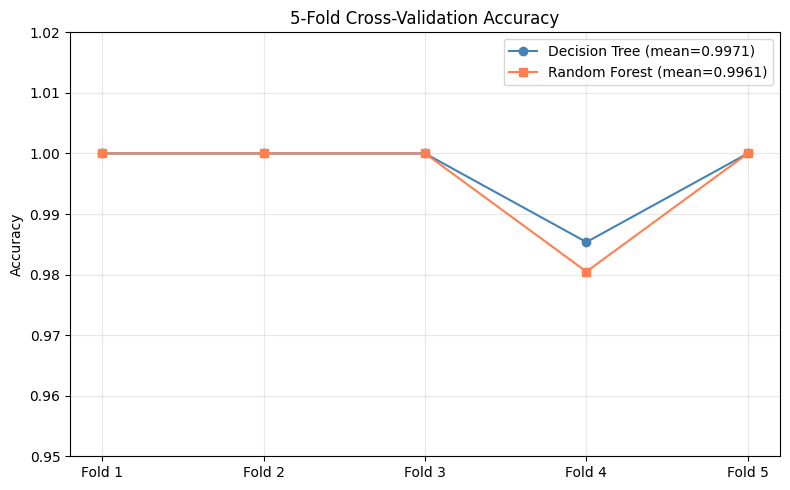

In [12]:
# Plot CV scores
fig, ax = plt.subplots(figsize=(8, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
ax.plot(x, dt_cv_scores, 'o-', label=f'Decision Tree (mean={dt_cv_scores.mean():.4f})', color='steelblue')
ax.plot(x, rf_cv_scores, 's-', label=f'Random Forest (mean={rf_cv_scores.mean():.4f})', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.95, 1.02)
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()